# Does wifi make students smarter?



In [2]:
# Load Data
%pip install numpy pandas matplotlib seaborn openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
historical_paths = ['data/Historical_SY10-to-SY14.xlsx', 'data/Historical_SY15-to-SY21.xlsx']


####### Get all sheet names from the first historical file
xls = pd.ExcelFile(historical_paths[0])
sheet_names = xls.sheet_names
print("Sheet names in the first historical file:", sheet_names)

# Read each sheet into a dictionary of DataFrames
sheets_dict = {sheet_name: pd.read_excel(historical_paths[0], 
                        sheet_name=sheet_name, 
                        na_values=['**', 'N/A', 'n/a', 'NA'],
                        usecols = "A:F,BB,CX",
                        skiprows=1) 
                    for sheet_name in sheet_names}

# Fix column titles, adding the year to each column and renaming the last two columns
for sheet_name, df in sheets_dict.items():
    print(sheet_name)

    # lowercase all column names and remove spaces 
    df.columns = [col.lower().replace(' ', '') for col in df.columns]

    df.rename(columns={df.columns[-1]: 'math_proficiency', df.columns[-2]: 'english_proficiency'}, inplace=True)

    year = '20' + str(sheet_name).split('-')[1]  # Extract the year from the sheet name
    df['year'] = int(year)

    sheets_dict[sheet_name] = df

# Concatenate all DataFrames into a single DataFrame
df_10_to_14 = pd.concat(sheets_dict.values(), ignore_index=True)




####### Get all sheet names from the second historical file
xls = pd.ExcelFile(historical_paths[1])
sheet_names = xls.sheet_names
print("Sheet names in the second historical file:", sheet_names)

# Read each sheet into a dictionary of DataFrames
sheets_dict = {sheet_name: pd.read_excel(historical_paths[1], 
                        sheet_name=sheet_name, 
                        na_values=['**', 'N/A', 'n/a', 'NA'],
                        usecols = "A:F,AT,CH",
                        skiprows=1) 
                    for sheet_name in sheet_names if sheet_name != '# Students Tested'}

# Fix column titles, adding the year to each column and renaming the last two columns
for sheet_name, df in sheets_dict.items():
    print(sheet_name)

    # lowercase all column names and remove spaces
    df.columns = [col.lower().replace(' ', '') for col in df.columns]
    df.rename(columns={df.columns[-1]: 'math_proficiency', df.columns[-2]: 'english_proficiency'}, inplace=True)

    # Extract the year from the sheet name, SY21 School & District
    year = '20' + str(sheet_name)[2:4]
    df['year'] = int(year)

    sheets_dict[sheet_name] = df



# Concatenate all DataFrames into a single DataFrame
df_15_to_21 = pd.concat(sheets_dict.values(), ignore_index=True)

df = pd.concat([df_10_to_14, df_15_to_21], ignore_index=True)

df

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Sheet names in the first historical file: ['SY09-10', 'SY10-11', 'SY11-12', 'SY12-13', 'SY13-14']
SY09-10
SY10-11
SY11-12
SY12-13
SY13-14
Sheet names in the second historical file: ['SY21 School & District', 'SY19 School & District', 'SY18 School & District', 'SY17 School & District', 'SY16 School & District', 'SY15 School & District', '# Students Tested']
SY21 School & District
SY19 School & District
SY18 School & District
SY17 School & District
SY16 School & District
SY15 School & District


,district,county,school,schoolname,populationgroup,subgroup,english_proficiency,math_proficiency,year
0,2,Barbour,101.0,Kasson Elementary/Middle School,Gender,Female,61.111111,66.666667,2010
1,2,Barbour,101.0,Kasson Elementary/Middle School,Gender,Male,60.714286,44.642857,2010
2,2,Barbour,101.0,Kasson Elementary/Middle School,Race/Ethnicity,Asian,50.000000,50.000000,2010
3,2,Barbour,101.0,Kasson Elementary/Middle School,Race/Ethnicity,Black or African American,100.000000,50.000000,2010
4,2,Barbour,101.0,Kasson Elementary/Middle School,Race/Ethnicity,White,60.377358,55.660377,2010
...,...,...,...,...,...,...,...,...,...
75446,999,Statewide,999.0,State Total,Total Population,Total,29.988600,46.356700,2015
75447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015
75448,Please Note,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015
75449,** Indicates that the rate has been suppressed...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015


In [3]:
# Filter out total rows
df_summary = df[ df['populationgroup'] == 'Total Population' ].copy()
df_summary = df_summary.drop(columns=['populationgroup'])
df_summary = df_summary[ df_summary['county'] != 'Statewide']
df_summary = df_summary[ df_summary['school'] != 999 ]

# Fix school name by removing: (Closed)   . and School and replacing / with -
df_summary['schoolname'] = df_summary['schoolname'].str.replace('/', '-', regex=False)
df_summary['schoolname'] = df_summary['schoolname'].str.replace(' (Closed)', '', regex=False)
df_summary['schoolname'] = df_summary['schoolname'].str.replace('.', '', regex=False)
df_summary['schoolname'] = df_summary['schoolname'].str.replace(' School', '', regex=False)

# Build unique school name by combining county and school name
df_summary['schoolname'] = df_summary['county'].str.rstrip() + ', ' + df_summary['schoolname'].str.rstrip()

# Pivot the data wider to show each year as a column
df_pivot = df_summary.pivot_table(index=['schoolname'], columns='year', values='math_proficiency', aggfunc='count')

# How many unique schools do we have per year?
df_unique_schools = df_summary.groupby(by='schoolname').agg({ 'schoolname': 'count'})
print('Unique schools per year', df_unique_schools.shape[0])

# How many unique schools in 2014 do we have?
df_unique_schools_2014 = df_summary[df_summary['year'] == 2014].groupby(by='schoolname').agg({ 'schoolname': 'count'})
print('Unique schools in 2014:', df_unique_schools_2014.shape[0])

# How many unique years do we have?
df_unique_years = df_summary.groupby(by='year').agg({ 'year': 'count'})

print('Unique years in the dataset:', df_unique_years.shape[0])

Unique schools per year 799
Unique schools in 2014: 656
Unique years in the dataset: 11


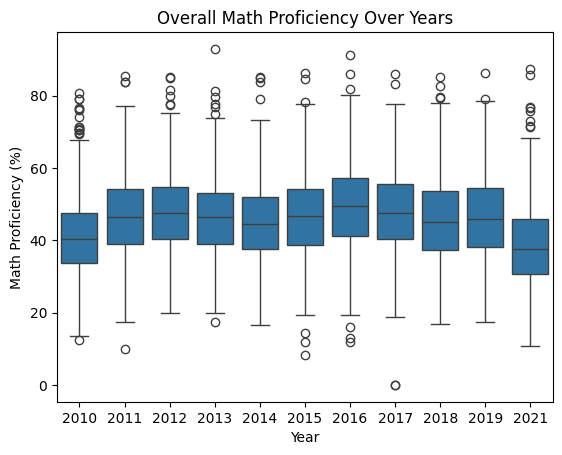

In [4]:
# Graph overall math scores by year
# Graph overall math scores by year
sns.boxplot(data=df_summary, y='math_proficiency', x='year')
plt.title('Overall Math Proficiency Over Years')
plt.xlabel('Year')
plt.ylabel('Math Proficiency (%)')
plt.show()

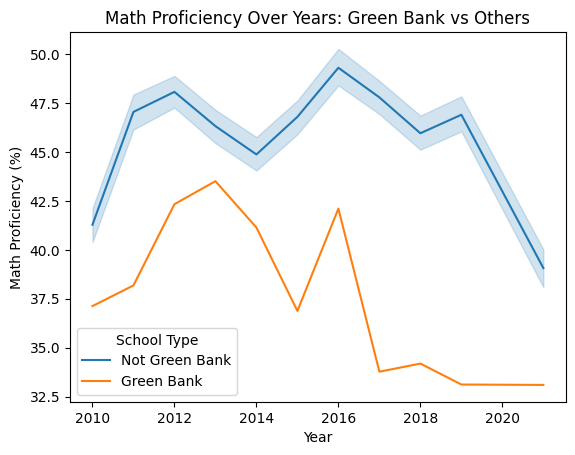

In [5]:
# Graph Greenbank School against all others 
# Hint:  Pocahontas, Green Bank Elementary-Middle

# Add is_greenbank column
# hint: use df.loc[:, 'fieldname'] = np.where(test, value_if_true, value_if_false)
# This will add a a new column to the dataset based on the where condition.
df_summary['is_greenbank'] = np.where( df_summary['schoolname'] == 'Pocahontas, Green Bank Elementary-Middle', 'Green Bank', 'Not Green Bank')

# Create graph with line chart
sns.lineplot(data=df_summary, x='year', y='math_proficiency', hue='is_greenbank')
plt.title('Math Proficiency Over Years: Green Bank vs Others')
plt.xlabel('Year')
plt.ylabel('Math Proficiency (%)')
plt.legend(title='School Type')
plt.show()


In [6]:
# Confusion matrix example
# Compare the schools with above math proficiency of 50% vs those below 50%
df_predict = df_summary.copy()

df_predict['math_above_50'] = np.where(df_predict['math_proficiency'] > 50, 1, 0)
df_predict['english_above_50'] = np.where(df_predict['english_proficiency'] > 1, 1, 0)

# Group to find the number of schools in each confusion category
df_confusion = df_predict.groupby(['math_above_50', 'english_above_50']).agg({'schoolname': 'count'})
df_confusion


schoolname
math_above_50 english_above_50            
0             0                          3
              1                       4693
1             0                          1
              1                       2416

Correlation between Math and English Proficiency: 0.65 (p-value: 0.0000)


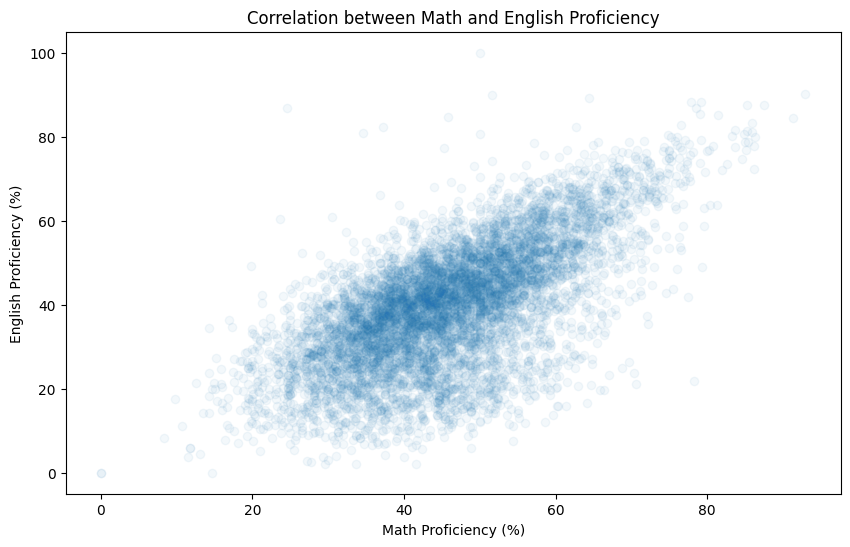

In [7]:
# Show correlation between math and english proficiency
from scipy.stats import pearsonr

# Create a new df that only has math and english proficiency, and has no null values
df_corr = df_summary[['math_proficiency', 'english_proficiency']].dropna()

# Calculate correlation
correlation, p_value = pearsonr(df_corr['math_proficiency'], df_corr['english_proficiency'])
print(f'Correlation between Math and English Proficiency: {correlation:.2f} (p-value: {p_value:.4f})')

# Graph correlation between math and english proficiency
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_corr['math_proficiency'], df_corr['english_proficiency'], alpha=0.05)
plt.title('Correlation between Math and English Proficiency')
plt.xlabel('Math Proficiency (%)')
plt.ylabel('English Proficiency (%)')
plt.show()


RMSE of Proficiency Difference: 12.73%


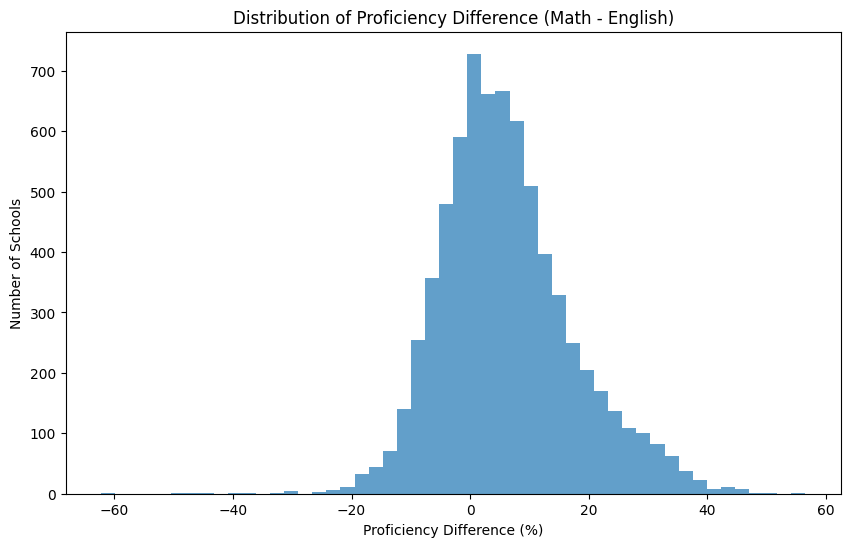

In [8]:
# Calculate residuals of math proficiency vs english proficiency

# Calculate difference between math and english proficiency, which is the "error" of our simple model
df_summary['proficiency_diff'] = df_summary['math_proficiency'] - df_summary['english_proficiency']

# Calculate the RSME of the difference
rmse = np.sqrt(np.mean(df_summary['proficiency_diff'].dropna() ** 2))
print(f'RMSE of Proficiency Difference: {rmse:.2f}%')

# Graph
plt.figure(figsize=(10, 6))
plt.hist(df_summary['proficiency_diff'].dropna(), bins=50, alpha=0.7)
plt.title('Distribution of Proficiency Difference (Math - English)')
plt.xlabel('Proficiency Difference (%)')
plt.ylabel('Number of Schools')
plt.show()
